# 04 — Cohort Retention Analysis

**Project:** E-Commerce Customer & Revenue Analytics

**Business question this notebook contributes to:** where should the company focus to improve customer retention? Specifically — does retention quality change across acquisition cohorts, and does that help explain the declining new-customer revenue found in `notebooks/02`?

**Purpose of this notebook:**

1. Assign every customer to an acquisition ("cohort") month
2. Compute how many months after acquisition each of their orders happened
3. Build a cohort × months-since-acquisition retention matrix
4. Visualize it as a heatmap
5. Compare retention trends across earlier vs. later cohorts
6. Validation asserts
7. Save the retention matrix
8. Summary of observations

**Input:** `data/processed/fact_sales_completed.csv` — same validated, Completed-only fact table used in `01`–`03`.

**Definition used here (consistent with `notebooks/02` Section 7 and `notebooks/03`):** a customer's cohort is their **first Completed-order month**, not their `signup_date` — `notebooks/01` found 55 orders predating the recorded `signup_date`, so first purchase month is the more reliable acquisition marker in this dataset.

**A structural limitation worth stating upfront:** the data only runs through December 2024, so later cohorts (e.g. November, December) simply haven't had as many months to *be* retained yet as the January cohort has. The retention matrix will be triangular for this reason — that's expected, not a data quality issue, but it means later cohorts can't be fairly compared to earlier ones beyond the number of months both have actually had a chance to show.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

fact_sales = pd.read_csv(
    DATA_PROCESSED / "fact_sales_completed.csv",
    parse_dates=["order_date", "order_month", "signup_date"],
)
print("fact_sales_completed shape:", fact_sales.shape)
print("date range:", fact_sales["order_date"].min().date(), "to", fact_sales["order_date"].max().date())

fact_sales_completed shape: (1625, 16)
date range: 2024-01-01 to 2024-12-30


## 1. Assign each customer's cohort month

In [2]:
cohort_month = fact_sales.groupby("customer_id")["order_month"].min().rename("cohort_month")
fact_sales = fact_sales.merge(cohort_month, on="customer_id", how="left")

cohort_sizes_check = fact_sales.groupby("cohort_month")["customer_id"].nunique().sort_index()
print("Customers acquired per cohort month:")
print(cohort_sizes_check)
print("\nTotal customers across all cohorts:", cohort_sizes_check.sum(), "(should match notebooks/02's 267)")

Customers acquired per cohort month:
cohort_month
2024-01-01    61
2024-02-01    36
2024-03-01    41
2024-04-01    23
2024-05-01    24
2024-06-01    18
2024-07-01    13
2024-08-01    16
2024-09-01    14
2024-10-01    11
2024-11-01     6
2024-12-01     4
Name: customer_id, dtype: int64

Total customers across all cohorts: 267 (should match notebooks/02's 267)


## 2. Compute months since acquisition for every order

In [3]:
def months_between(later, earlier):
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

fact_sales["period_number"] = months_between(fact_sales["order_month"], fact_sales["cohort_month"])

print("period_number range:", fact_sales["period_number"].min(), "to", fact_sales["period_number"].max())
assert (fact_sales["period_number"] >= 0).all(), "An order can't happen before its own cohort month"
fact_sales[["customer_id", "cohort_month", "order_month", "period_number"]].head()

period_number range: 0 to 11


,customer_id,cohort_month,order_month,period_number
0,256,2024-02-01,2024-08-01,6
1,54,2024-01-01,2024-06-01,5
2,152,2024-02-01,2024-04-01,2
3,159,2024-10-01,2024-10-01,0
4,60,2024-09-01,2024-12-01,3


## 3. Build the retention matrix

Rows = cohort month, columns = months since acquisition (period 0, 1, 2, ...), values = number of **distinct customers** from that cohort who placed a Completed order in that period. Period 0 is, by definition, the entire cohort — every member's first purchase created their cohort assignment.

In [4]:
cohort_activity = (
    fact_sales.groupby(["cohort_month", "period_number"])["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

retention_counts = cohort_activity.pivot(index="cohort_month", columns="period_number", values="active_customers")

cohort_sizes = retention_counts[0]
assert (cohort_sizes == cohort_sizes_check).all(), "Period-0 count must equal each cohort's total size"

retention_pct = retention_counts.div(cohort_sizes, axis=0) * 100

retention_counts.index = retention_counts.index.strftime("%Y-%m")
retention_pct.index = retention_pct.index.strftime("%Y-%m")

print("Cohort sizes (period 0):")
print(cohort_sizes.values)
print("\nRetention % matrix:")
display(retention_pct.round(1))

Cohort sizes (period 0):
[61. 36. 41. 23. 24. 18. 13. 16. 14. 11.  6.  4.]

Retention % matrix:


period_number,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2024-01,100.0,11.5,26.2,18.0,18.0,14.8,9.8,29.5,18.0,19.7,23.0,11.5
2024-02,100.0,11.1,16.7,13.9,19.4,5.6,5.6,30.6,25.0,8.3,16.7,NaN
2024-03,100.0,22.0,14.6,9.8,17.1,12.2,9.8,24.4,22.0,12.2,NaN,NaN
2024-04,100.0,8.7,30.4,13.0,17.4,8.7,21.7,21.7,21.7,NaN,NaN,NaN
2024-05,100.0,12.5,12.5,20.8,4.2,20.8,16.7,20.8,NaN,NaN,NaN,NaN
2024-06,100.0,22.2,16.7,16.7,16.7,27.8,16.7,NaN,NaN,NaN,NaN,NaN
2024-07,100.0,30.8,15.4,46.2,15.4,30.8,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.0,43.8,31.2,18.8,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,7.1,7.1,42.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Retention heatmap

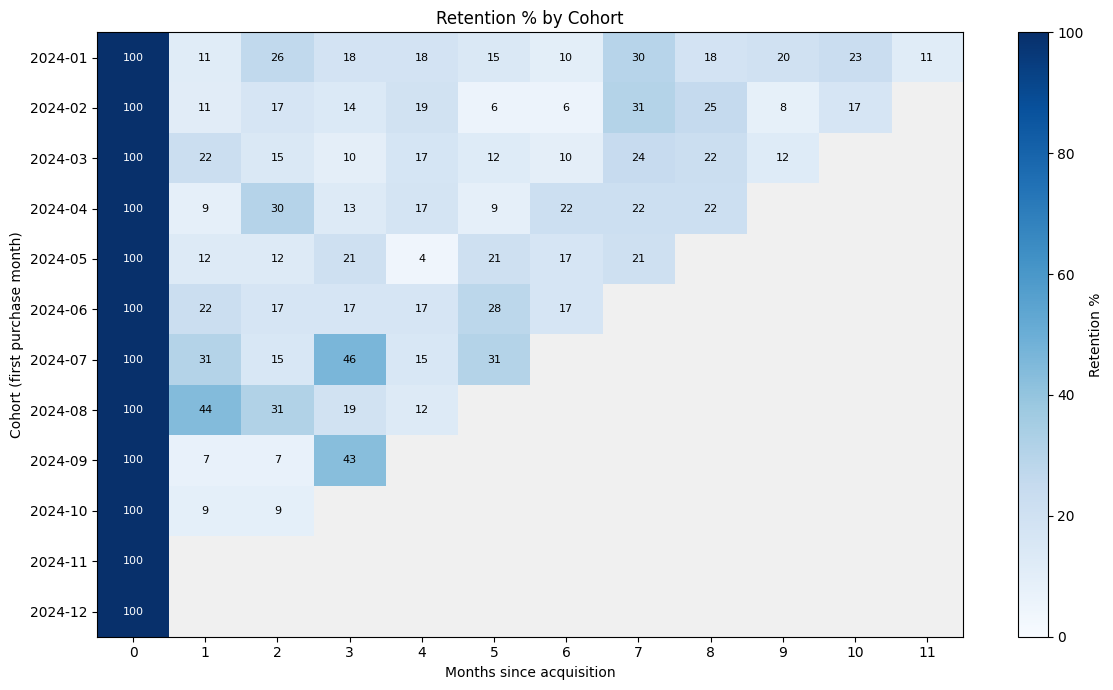

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))
data = retention_pct.values
masked = np.ma.masked_invalid(data)

cmap = plt.cm.Blues.copy()
cmap.set_bad(color="#f0f0f0")
im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(retention_pct.shape[1]))
ax.set_xticklabels(retention_pct.columns)
ax.set_yticks(range(retention_pct.shape[0]))
ax.set_yticklabels(retention_pct.index)
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("Cohort (first purchase month)")
ax.set_title("Retention % by Cohort")

for i in range(retention_pct.shape[0]):
    for j in range(retention_pct.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                     color="white" if val > 50 else "black", fontsize=8)

fig.colorbar(im, ax=ax, label="Retention %")
fig.tight_layout()
fig.savefig(FIGURES / "10_cohort_retention_heatmap.png", dpi=150)
plt.show()

## 5. Retention trend: overall curve, and earlier vs. later cohorts

The overall curve averages retention % at each period across every cohort that has actually reached that period (pandas' `.mean()` skips `NaN` automatically — a cohort that hasn't reached period 6 yet simply doesn't contribute to period 6's average, rather than being counted as 0%).

To compare earlier vs. later cohorts fairly given the triangular data, only **period 1** (the first full month after acquisition) is used, since it's the only later period every single cohort except the very last one has actually reached.

Average retention % by period (across all cohorts that reached it):
period_number
0     100.0
1      17.9
2      18.0
3      22.2
4      15.1
5      17.2
6      13.4
7      25.4
8      21.7
9      13.4
10     19.8
11     11.5
dtype: float64


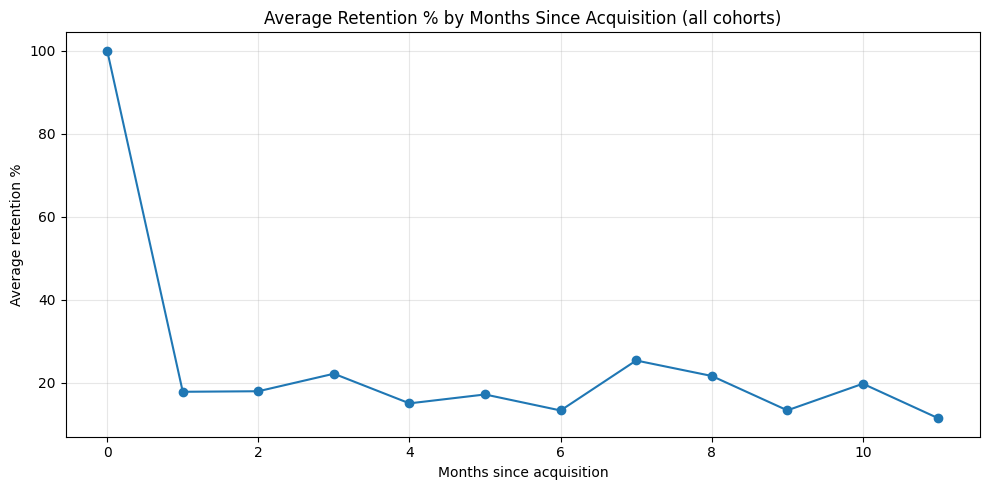

In [6]:
avg_retention_by_period = retention_pct.mean(axis=0, skipna=True)
print("Average retention % by period (across all cohorts that reached it):")
print(avg_retention_by_period.round(1))

fig, ax = plt.subplots()
ax.plot(avg_retention_by_period.index, avg_retention_by_period.values, marker="o", color="#1f77b4")
ax.set_title("Average Retention % by Months Since Acquisition (all cohorts)")
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("Average retention %")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "11_avg_retention_curve.png", dpi=150)
plt.show()

In [7]:
period_1 = retention_pct[1].dropna()
half = len(period_1) // 2
earlier_cohorts = period_1.iloc[:half]
later_cohorts = period_1.iloc[half:]

print("Period-1 retention %, earlier cohorts:")
print(earlier_cohorts.round(1))
print(f"Average: {earlier_cohorts.mean():.1f}%")

print("\nPeriod-1 retention %, later cohorts:")
print(later_cohorts.round(1))
print(f"Average: {later_cohorts.mean():.1f}%")

Period-1 retention %, earlier cohorts:
cohort_month
2024-01    11.5
2024-02    11.1
2024-03    22.0
2024-04     8.7
2024-05    12.5
Name: 1, dtype: float64
Average: 13.1%

Period-1 retention %, later cohorts:
cohort_month
2024-06    22.2
2024-07    30.8
2024-08    43.8
2024-09     7.1
2024-10     9.1
Name: 1, dtype: float64
Average: 22.6%


## 6. Validation asserts

In [8]:
assert retention_pct.shape[0] == fact_sales["cohort_month"].nunique(), "One row per cohort month expected"
assert (retention_pct[0] == 100).all(), "Period 0 retention must always be 100% by construction"
non_null = retention_pct.values[~np.isnan(retention_pct.values)]
assert ((non_null >= 0) & (non_null <= 100)).all(), "Retention % must be between 0 and 100"
assert cohort_sizes.sum() == fact_sales["customer_id"].nunique(), "Cohort sizes must sum to total customers"

print("All validation checks passed.")

All validation checks passed.


## 7. Save the retention matrix

In [9]:
retention_pct_out = retention_pct.reset_index().rename(columns={"index": "cohort_month"})
retention_pct_out.to_csv(DATA_PROCESSED / "cohort_retention_matrix.csv", index=False)
print("Saved:", DATA_PROCESSED / "cohort_retention_matrix.csv", retention_pct_out.shape)

Saved: /Users/yvonne/Desktop/E-commerce Analytics/data/processed/cohort_retention_matrix.csv (12, 13)


## 8. Summary of observations

- **This notebook resolves the open question from `notebooks/02`: the decline in new-customer revenue is an acquisition problem, not a retention problem.** Cohort size falls steadily and almost monotonically all year — 61 new customers in January down to just 4 in December. That's the direct cause of `notebooks/02`'s finding that new-customer revenue dollars fell from $30,948 (Jan) to ~$2,000 (Nov/Dec): there are simply far fewer new customers being acquired each month, not existing customers buying less.
- **Retention itself does not show a clear declining trend across cohorts** — if anything, the opposite. Period-1 retention (first month after acquisition) averages 13.1% for the five earliest cohorts (Jan–May) vs. 22.6% for the next five (Jun–Oct). This should be read cautiously given the small cohort sizes involved (Aug's 43.8% is 7 of only 16 customers, for example — a couple of customers swing the percentage a lot), but there's no evidence retention quality is getting worse for later, smaller cohorts.
- **Retention is generally low and noisy for every cohort, not just later ones.** Average retention by months-since-acquisition bounces between roughly 11% and 25% with no strong monotonic decay pattern (period 1 averages 17.9%, period 11 averages 11.5%, and periods in between vary non-monotonically). Most customers who return don't return in every subsequent month — they come back sporadically rather than following a smooth, predictable decay curve.
- **Practical takeaway:** retention/win-back efforts (e.g. the At Risk segment from `notebooks/03`) remain worthwhile, but they're not the lever that explains this year's flat revenue. The most direct lever for revenue growth is the top of the funnel — the volume of new customers coming in each month has been shrinking steadily, and reversing that (rather than optimizing post-purchase retention further) is where investigation should start.

`cohort_retention_matrix.csv` (12 cohorts × 12 period columns, retention %) is saved to `data/processed/` for reuse in Power BI and `reports/findings.md`.